In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
import torch

In [2]:
X = np.load('data_window.npy')
y = np.load('label_window.npy')
y1 = np.load('label_window_1.npy')
print(X[:, :, 0].shape)
X = X[:10000, :, 0]
print(y.shape)
y = y[:10000]
print(y.shape)

(177313, 120)
(177313,)
(10000,)


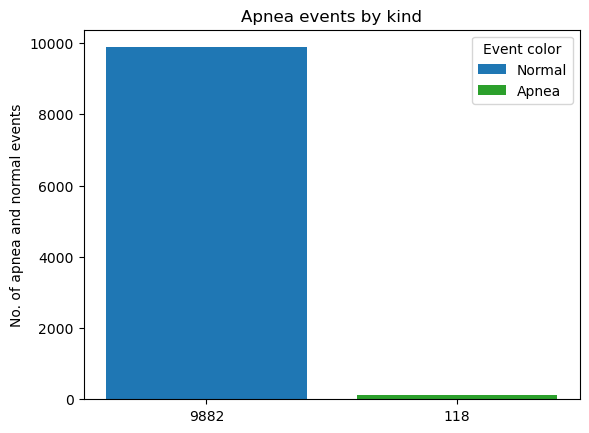

In [3]:
#counting the occurrence of a certain class in y
unique, counts = np.unique(y, return_counts=True)
D=dict(zip(unique, counts))
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
bar_labels = ['Normal', 'Apnea']
bars=list(D.values())
x_pos = (np.arange(len(bars)))
bar_colors = ['tab:blue', 'tab:green']
ax.bar(range(len(D)), bars, align='center',label=bar_labels, color=bar_colors )
ax.set_ylabel('No. of apnea and normal events')
ax.set_title('Apnea events by kind')
ax.legend(title='Event color')
# Create names on the x-axis
plt.xticks(x_pos, bars)
plt.show()

In [4]:
vals_dict = {}
for i in y:
    if i in vals_dict.keys():
        vals_dict[i] += 1
    else:
        vals_dict[i] = 1
total = sum(vals_dict.values())
print(vals_dict)
# Formula used - Naive method where
# weight = 1 - (no. of samples present / total no. of samples)
# So more the samples, lower the weight
weight_dict = {int(k): (1 - (v / total)) for k, v in vals_dict.items()}

print(weight_dict)

{np.int64(0): 9882, np.int64(1): 118}
{0: 0.011800000000000033, 1: 0.9882}


In [5]:
vals_dict1 = {}
for i in y1:
    if i in vals_dict1.keys():
        vals_dict1[i] += 1
    else:
        vals_dict1[i] = 1
total = sum(vals_dict1.values())
print(vals_dict1)

# Formula used - Naive method where
# weight = 1 - (no. of samples present / total no. of samples)
# So more the samples, lower the weight
weight_dict1 = {int(k): (1 - (v / total)) for k, v in vals_dict1.items()}

print(weight_dict1)

{np.int64(0): 172643, np.int64(1): 4670}
{0: 0.026337606379678857, 1: 0.9736623936203211}


In [24]:
x_train, x_test, y_train, y_test =train_test_split(
    X, y, test_size=0.2, #shuffle=True #random_state=42, shuffle=True
)
#y_train = np.asarray(y_train).astype(np.float32).reshape(-1, 1)

#y_test = np.asarray(y_test).astype(np.float32).reshape(-1, 1)
x_train = torch.tensor(x_train, dtype=torch.float)
x_test = torch.tensor(x_test, dtype=torch.float)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)
print('Test size', x_test.size())
print(y_test.size())

Test size torch.Size([2000, 120])
torch.Size([2000])


In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TransformerBlock(nn.Module):
    def __init__(self, d_model, head_size, num_heads, ff_dim, dropout):
        super().__init__()
        # In PyTorch embed_dim = d_model
        self.layernorm1 = nn.LayerNorm(d_model, eps=1e-6)
        self.mha = nn.MultiheadAttention(embed_dim=d_model, num_heads=num_heads, dropout=dropout, batch_first=True)
        self.dropout1 = nn.Dropout(dropout)

        self.layernorm2 = nn.LayerNorm(d_model, eps=1e-6)
        self.ffn = nn.Sequential(
            nn.Conv1d(d_model, ff_dim, kernel_size=1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(ff_dim, d_model, kernel_size=1)
        )
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x):
        # Normalization + Attention + Residual
        res = x
        x = self.layernorm1(x)
        attn_out, _ = self.mha(x, x, x)
        x = res + self.dropout1(attn_out)

        # Feed Forward + Residual
        res = x
        x = self.layernorm2(x)
        x = x.transpose(1, 2)
        x = self.ffn(x)
        x = x.transpose(1, 2)
        return res + self.dropout2(x)

class CustomAutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        # Architettura basata sul paper (132 -> 64 -> 1)
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 132, kernel_size=7, padding=3, stride=2),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Conv1d(132, 64, kernel_size=7, padding=3, stride=2),
            nn.ReLU()
        )

        
        # Upsampling per tornare alla lunghezza originale
        self.decoder = nn.ConvTranspose1d(64, 1, kernel_size=7, padding=3, stride=4, output_padding=3)

    def forward(self, x):
        # x: (batch, 1, seq_len)
        return self.decoder(self.encoder(x))
    

class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        # Primo strato: da 1 canale SpO2 a 132 feature
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=132, kernel_size=7, padding=3, stride=2)
        self.dropout = nn.Dropout(p=0.1)
        
        # SECONDO STRATO (Qui era l'errore): deve accettare 132 canali!
        self.conv2 = nn.Conv1d(in_channels=132, out_channels=64, kernel_size=7, padding=3, stride=2)
        
        # Strato di ricostruzione (Decoder)
        # Riporta a 1 canale per sommarlo all'input originale come Positional Encoding
        self.decoder = nn.ConvTranspose1d(in_channels=64, out_channels=1, kernel_size=7, padding=3, stride=4, output_padding=3)

    def forward(self, x):
        # x shape: (batch, 1, 80)
        #print('x', x.size())
        x_enc = F.relu(self.conv1(x))
        x_enc = self.dropout(x_enc)
        x_enc = F.relu(self.conv2(x_enc))
        
        # Ricostruzione
        pos_encoding = self.decoder(x_enc)
        return pos_encoding
    
class ApneaTransformer(nn.Module):
    def __init__(self, n_classes, head_size, num_heads, ff_dim, num_blocks, mlp_units, dropout, mlp_dropout):
        super().__init__()

        # 1. AutoEncoder (Generatore di Positional Embedding)
        self.auto_pe = AutoEncoder()

        # 2. Input Projection
        # Trasformiamo l'input (1 canale) nella dimensione d_model del Transformer
        self.d_model = head_size * num_heads
        self.input_projection = nn.Linear(1, self.d_model)

        # 3. Transformer Encoder Blocks
        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(self.d_model, head_size, num_heads, ff_dim, dropout)
            for _ in range(num_blocks)
        ])

        # 4. MLP Head
        layers = []
        curr_in = self.d_model
        for dim in mlp_units:
            layers.append(nn.Linear(curr_in, dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(mlp_dropout))
            curr_in = dim

        self.mlp_head = nn.Sequential(*layers)
        self.classifier = nn.Linear(curr_in, n_classes)

    def forward(self, x):
        # x: (batch, 1, seq_len)

        # LOGICA PAPER: Sommiamo l'input originale al PE generato dall'AutoEncoder
        pe = self.auto_pe(x)
        x_combined = x + pe # Questa è la somma data-driven

        # Trasponiamo per il Transformer: (batch, seq, feat)
        x_combined = x_combined.transpose(1, 2)
        x_projected = self.input_projection(x_combined)

        # Blocchi Transformer
        for block in self.transformer_blocks:
            x_projected = block(x_projected)

        # Global Average Pooling (Lungo la dimensione temporale)
        x_pooled = x_projected.mean(dim=1)

        # MLP Head
        x_mlp = self.mlp_head(x_pooled)
        return self.classifier(x_mlp)

In [10]:
device='cpu'
model = ApneaTransformer(
    n_classes=2,
    head_size=256,
    num_heads=4,
    ff_dim=4,
    num_blocks=6,
    mlp_units=[256],
    dropout=0.1,
    mlp_dropout=0.2
).to(device)

In [ ]:
import torch.optim as optim
device = 'cpu'
# Parametri presi dal tuo codice Keras
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.0001)
# weight_dict deve essere un tensore con i pesi calcolati
weights = torch.tensor([weight_dict[0], weight_dict[1]], dtype=torch.float).to(device)
criterion = torch.nn.CrossEntropyLoss(weight=weights)
import torch
from torch.utils.data import DataLoader, TensorDataset

# Prepariamo i dati
train_ds = TensorDataset(
    torch.tensor(x_train).float(), 
    torch.tensor(y_train).long() # <-- Corretto se y_train è 1D
)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

# Scheduler (equivalente alla tua funzione scheduler)
scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9048) # exp(-0.1) ≈ 0.9048

best_val_loss = float('inf')
patience = 10
trigger_times = 0

for epoch in range(30):
    print('Epoch', epoch)
    model.train()
    for batch_x, batch_y in train_loader:
        batch_x = batch_x.unsqueeze(1)
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        # Forward pass
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Step dello scheduler dopo l'epoca 10 (come nel tuo codice)
    if epoch >= 10:
        scheduler.step()
    print('loss', loss.item()/len(train_loader))

    # # --- LOGICA VALIDAZIONE & EARLY STOPPING ---
    # model.eval()
    # val_loss = calculate_val_loss() # Funzione helper da definire

    # if val_loss < best_val_loss:
    #     best_val_loss = val_loss
    #     torch.save(model.state_dict(), "training_2/cp.ckpt")
    #     trigger_times = 0
    # else:
    #     trigger_times += 1
    #     if trigger_times >= patience:
    #         print("Early stopping!")
    #         break



/tmp/ipykernel_20792/854168526.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(x_train).float(),
/tmp/ipykernel_20792/854168526.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(y_train).long() # <-- Corretto se y_train è 1D


Epoch 0
loss 0.011375849723815917
Epoch 1
loss 0.018188472747802734
Epoch 2
loss 0.005561193943023682
Epoch 3
loss 0.004945862293243408
Epoch 4
loss 0.004474133014678955
Epoch 5
loss 0.001135974884033203
Epoch 6
loss 0.0064838905334472655
Epoch 7
loss 0.005953390121459961
Epoch 8
loss 0.003749532461166382
Epoch 9
loss 0.006138228416442871
Epoch 10
loss 0.006213470458984375
Epoch 11
loss 0.0034409637451171876
Epoch 12
loss 0.003437965154647827
Epoch 13
loss 0.006309032917022705
Epoch 14
loss 0.006331601619720459
Epoch 15
loss 0.006365921497344971
Epoch 16
loss 0.003295285940170288
Epoch 17
loss 0.006377422332763672
Epoch 18
loss 0.0032546865940093995
Epoch 19
loss 0.0032406795024871827
Epoch 20
loss 0.0032241332530975344
Epoch 21
loss 0.003231823444366455
Epoch 22
loss 0.007319859504699707
Epoch 23
loss 0.006429928302764893
Epoch 24
loss 0.0032116689682006837
Epoch 25
loss 0.0032162203788757325
Epoch 26
loss 0.0032090272903442384
Epoch 27
loss 0.003211413860321045
Epoch 28
loss 0.003196

ModuleNotFoundError: No module named 'torchmetrics'

In [15]:
from torchmetrics.classification import BinaryAccuracy, BinaryPrecision, BinaryRecall, BinaryF1Score, BinaryAUROC

# Inizializzazione
metric_acc = BinaryAccuracy().to(device)
metric_f1 = BinaryF1Score().to(device)
metric_auc = BinaryAUROC().to(device)

# Durante la valutazione:
with torch.no_grad():
    x_test = x_test.unsqueeze(1)
    preds = model(x_test)
    # Calcolo
    acc = metric_acc(preds.argmax(dim=1), y_test)
    f1 = metric_f1(preds.argmax(dim=1), y_test)
    auc = metric_auc(preds[:, 1], y_test)

In [16]:
print(acc)
print(f1)
print(auc)

tensor(0.9870)
tensor(0.)
tensor(0.5000)


In [17]:
torch.save(model.state_dict(), "autoenc_50ep.pth")

In [18]:
import torch
from torch.utils.data import DataLoader
from torchmetrics import MetricCollection, Accuracy, F1Score, AUROC, Precision, Recall, Specificity

# Inizializziamo le metriche (assumendo classificazione binaria come nel tuo esempio)
metrics = MetricCollection({
    'accuracy': Accuracy(task="binary"),
    'f1_score': F1Score(task="binary"),
    'auc': AUROC(task="binary"),
    'precision': Precision(task="binary"),
    'recall': Recall(task="binary"),
    'specificity': Specificity(task="binary")
})

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
metrics.to(device)

MetricCollection(
  (accuracy): BinaryAccuracy()
  (auc): BinaryAUROC()
  (f1_score): BinaryF1Score()
  (precision): BinaryPrecision()
  (recall): BinaryRecall()
  (specificity): BinarySpecificity()
)

In [ ]:
test_dataset = TensorDataset(x_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=32)

def evaluate_pytorch(model, test_loader, criterion):
    model.eval() # Imposta il modello in modalità valutazione
    metrics.reset()
    running_loss = 0.0
    
    with torch.no_grad(): # Disabilita il calcolo dei gradienti (risparmia memoria)
        for x_batch, y_batch in test_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            x_batch = x_batch.unsqueeze(1)
            # Forward pass
            outputs = model(x_batch)
            
            # Se il modello restituisce logits, applichiamo sigmoid per le metriche
            #probs = torch.sigmoid(outputs)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            
            # Calcolo Loss
            loss = criterion(outputs, y_batch.float())
            running_loss += loss.item()
            
            # Aggiornamento metriche
            metrics.update(probs, y_batch.int())

    # Calcolo finale
    total_loss = running_loss / len(test_loader)
    final_metrics = metrics.compute()
    
    print(f"Loss: {total_loss:.4f}")
    for key, value in final_metrics.items():
        print(f"{key}: {value.item():.4f}")

# Esecuzione
criterion = torch.nn.CrossEntropyLoss()
evaluate_pytorch(model.to(device), test_loader, criterion)

ValueError: Target size (torch.Size([32])) must be the same as input size (torch.Size([32, 2]))